**Import Libraries**

This section imports all the necessary libraries for data manipulation, visualization, model building, and evaluation.

In [1]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split


from sklearn.tree import DecisionTreeClassifier
from sklearn import tree


from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


import joblib

**Load Dataset**

This cell loads the `loan_prediction.csv` file into a pandas DataFrame named `df`. The `.head()` method is used to display the first few rows, providing a quick overview of the data structure.

In [2]:
df = pd.read_csv(
    "/content/Loan_prediction.csv"
)


df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
# Display the shape (number of rows and columns) of the DataFrame.
df.shape

(614, 13)

In [4]:
# Check detailed information about the DataFrame, including column data types and non-null counts.
# This helps in identifying missing values and understanding the data structure.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [5]:
# Calculate and display the sum of null (missing) values for each column.
# This step is crucial for identifying which columns require missing value imputation.
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,2900,0.0,71.0,360.0,1.0,0,1
610,1,1,3,0,0,4106,0.0,40.0,180.0,1.0,0,1
611,1,1,1,0,0,8072,240.0,253.0,360.0,1.0,2,1
612,1,1,2,0,0,7583,0.0,187.0,360.0,1.0,2,1


**Remove Unnecessary Column**

This section identifies and removes columns that are not useful for prediction.

In [6]:
# 'Loan_ID' is a unique identifier and does not contribute to the prediction of loan status.
# Therefore, it is dropped from the DataFrame using `df.drop()` with `axis=1` (for columns)
# and `inplace=True` to modify the DataFrame directly.
df.drop(
    "Loan_ID",
    axis=1,
    inplace=True
)

**Handle Missing Values**

This part of the notebook addresses missing data in both categorical and numerical columns to ensure data quality for model training.

**1. Categorical Columns**

For categorical features, missing values are typically filled using the mode (most frequent value).

In [7]:
cat_cols = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area"
]

# Iterate through each categorical column to fill missing values.
# Missing values in each column are filled with the mode (most frequent value) of that column.
# Direct assignment (`df[col] = ...`) is used to ensure the DataFrame is modified correctly and to avoid `FutureWarning` related to `inplace=True`.
for col in cat_cols:
    df[col] = df[col].fillna(
        df[col].mode()[0]
    )


In [8]:
cat_cols


['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Property_Area']

In [9]:
# Re-check for missing values after handling categorical columns.
# This confirms that missing values in the specified categorical columns have been addressed.
df.isnull().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50


**2. Numerical Columns**

For numerical features, missing values are commonly filled using the median to avoid skewing the distribution with outliers.

In [10]:
num_cols = [
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

# Iterate through each numerical column to fill missing values.
# Missing values in each column are filled with the median value of that column.
# Direct assignment (`df[col] = ...`) is used for the same reasons as with categorical columns.
for col in num_cols:
    df[col] = df[col].fillna(
        df[col].median()
    )


['LoanAmount', 'Loan_Amount_Term', 'Credit_History']

In [11]:
# Final check for any remaining missing values in the entire DataFrame.
# All columns should now show 0 missing values, indicating successful imputation.
df.isnull().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


**Encoding Categorical Data**

Machine learning models typically require numerical input, so categorical features must be converted into numerical representations.

In [ ]:
# Import LabelEncoder from scikit-learn for converting categorical labels into numerical labels.
from sklearn.preprocessing import LabelEncoder

# Initialize the LabelEncoder.
encoder = LabelEncoder()

# Apply Label Encoding to each categorical column previously identified.
# `fit_transform` learns the unique labels and transforms them into numerical values (0, 1, 2, ...).
for col in cat_cols:
    df[col] = encoder.fit_transform(
        df[col]
    )

**Encode Target:**

The target variable (`Loan_Status`) also needs to be converted into a numerical format for model training.

In [ ]:
# Encode the 'Loan_Status' column, which is the target variable.
# 'Y' (Yes) will be mapped to 1 and 'N' (No) to 0, or vice versa, depending on the order LabelEncoder finds them.
df["Loan_Status"] = encoder.fit_transform(
    df["Loan_Status"]
)

# Yes ->1 and N->0 (Comment confirming the typical mapping if 'Y' is processed after 'N' or sorted accordingly)

**Separate Features and Target**

The dataset is divided into independent variables (features, `X`) and the dependent variable (target, `y`).

**Independent Variables:**

These are the features used to predict the target variable.

In [ ]:
# Create the feature matrix `X` by dropping the 'Loan_Status' column from the DataFrame.
# `axis=1` indicates that a column is being dropped.
X = df.drop(
    "Loan_Status",
    axis=1
)

In [ ]:
# Display the `X` DataFrame to inspect the independent variables.
X

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2
...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,2900,0.0,71.0,360.0,1.0,0
610,1,1,3,0,0,4106,0.0,40.0,180.0,1.0,0
611,1,1,1,0,0,8072,240.0,253.0,360.0,1.0,2
612,1,1,2,0,0,7583,0.0,187.0,360.0,1.0,2


**Dependent Variable:**

This is the target variable that the model will try to predict.

In [ ]:
# Create the target vector `y` by selecting only the 'Loan_Status' column from the DataFrame.
y = df["Loan_Status"]

In [ ]:
# Display the `y` Series to inspect the dependent variable.
y

,Loan_Status
0,1
1,0
2,1
3,1
4,1
...,...
609,1
610,1
611,1
612,1


**Train-Test Split**

The dataset is split into training and testing sets to evaluate the model's performance on unseen data.

In [ ]:
# Split the data into training and testing sets.
# `X` and `y` are the feature and target data.
# `test_size=0.2` allocates 20% of the data to the test set.
# `random_state=42` ensures reproducibility of the split.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Create Decision Tree Model**

An instance of the Decision Tree Classifier is created with specified parameters.

In [ ]:
# Initialize a DecisionTreeClassifier model.
# `criterion="gini"` specifies the Gini impurity for measuring the quality of a split.
# `random_state=42` ensures reproducibility of the model's randomness.
model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

**Train Model**

The Decision Tree model is trained using the training data.

In [ ]:
# Train the Decision Tree model using the training features (`X_train`) and training target (`y_train`).
# The `fit()` method learns the relationships between features and the target.
model.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(random_state=42)

**Prediction**

Once the model is trained, it's used to make predictions on the test set.

In [ ]:
# Make predictions on the test set (`X_test`) using the trained model.
# These predictions (`y_pred`) will be compared against the actual test labels (`y_test`).
y_pred = model.predict(
    X_test
)

## **Evaluation**

This section evaluates the performance of the trained Decision Tree model using various metrics.

**Accuracy**

Accuracy measures the proportion of correctly classified instances.

In [ ]:
# Calculate the accuracy score of the model by comparing the predicted values (`y_pred`) with the actual test values (`y_test`).
accuracy = accuracy_score(
    y_test,
    y_pred
)

# Print the calculated accuracy.
print(
accuracy
)

0.6910569105691057


**Confusion Matrix**

A confusion matrix provides a detailed breakdown of correct and incorrect classifications for each class.

In [ ]:
# Generate the confusion matrix, which summarizes the performance of a classification algorithm.
# It shows the number of true positives, true negatives, false positives, and false negatives.
cm = confusion_matrix(
    y_test,
    y_pred
)

# Print the confusion matrix.
print(cm)

[[23 20]
 [18 62]]


**Classification Report**

The classification report provides precision, recall, f1-score, and support for each class.

In [ ]:
# Print the classification report, which includes precision, recall, f1-score, and support for each class.
# This provides a more comprehensive evaluation than just accuracy, especially for imbalanced datasets.
print(
classification_report(
    y_test,
    y_pred
)
)

              precision    recall  f1-score   support

           0       0.56      0.53      0.55        43
           1       0.76      0.78      0.77        80

    accuracy                           0.69       123
   macro avg       0.66      0.65      0.66       123
weighted avg       0.69      0.69      0.69       123



**Visualize Decision Tree**

Visualizing the decision tree helps to understand the decision-making process of the model.

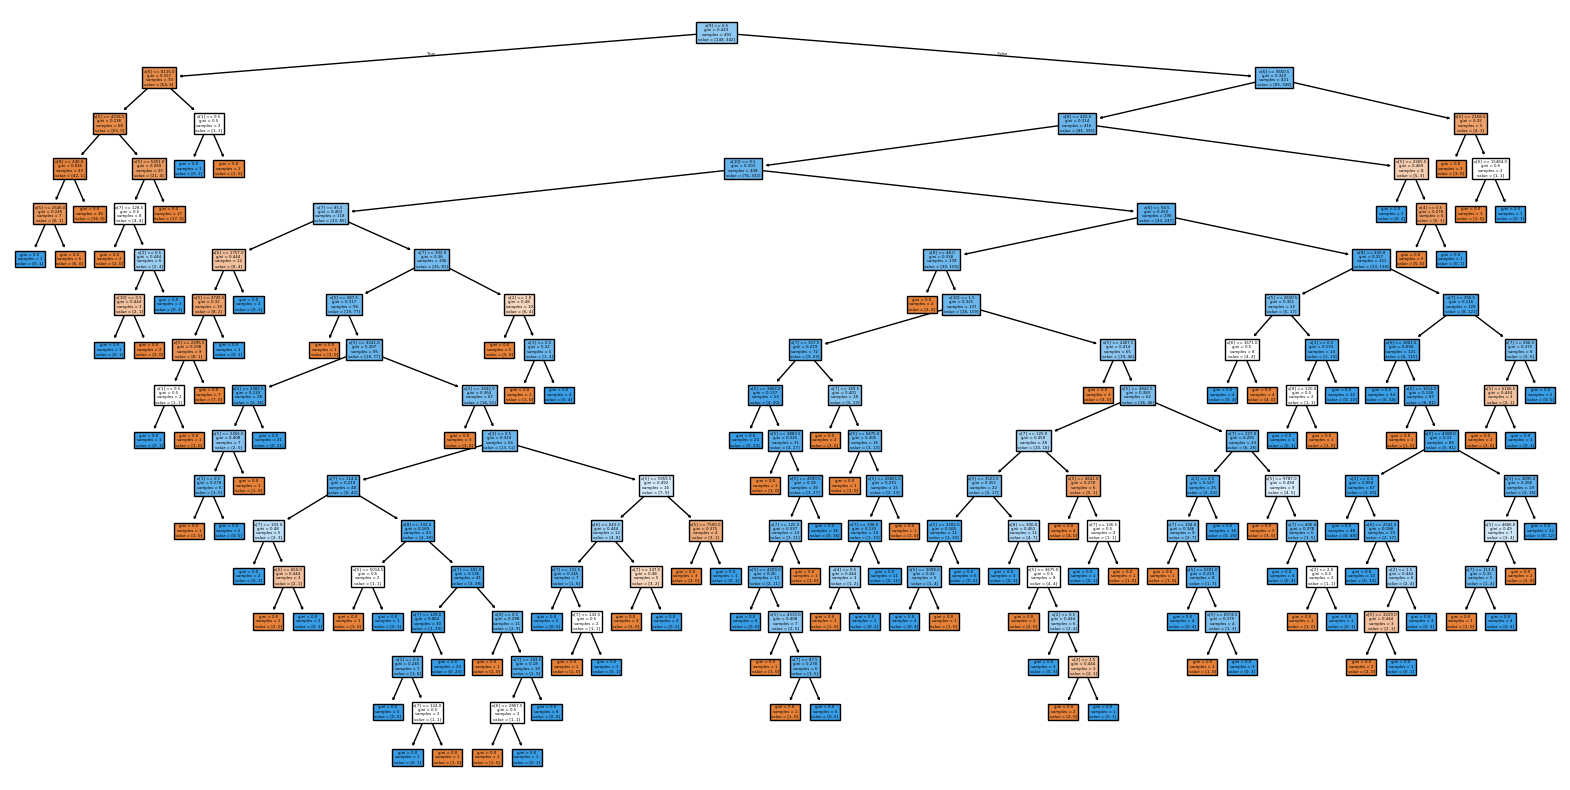

In [ ]:
# Create a figure with a specified size for better visualization of the tree.
plt.figure(
figsize=(20,10)
)

# Plot the decision tree.
# `model` is the trained Decision Tree Classifier.
# `filled=True` colors the nodes to indicate the majority class.
tree.plot_tree(
    model,
    filled=True
)

# Display the plot.
plt.show()

**Feature Importance**

Feature importance helps in understanding which features contributed most to the model's predictions.

In [ ]:
# Create a DataFrame to store feature names and their corresponding importance scores from the model.
importance = pd.DataFrame(
{
"Feature":X.columns,
"Importance":model.feature_importances_
}
)

# Sort the features by importance in descending order to easily identify the most impactful features.
importance.sort_values(
by="Importance",
ascending=False
)

,Feature,Importance
9,Credit_History,0.293493
5,ApplicantIncome,0.244570
7,LoanAmount,0.172321
6,CoapplicantIncome,0.098029
2,Dependents,0.050823
8,Loan_Amount_Term,0.046094
1,Married,0.032243
10,Property_Area,0.029587
4,Self_Employed,0.014453
3,Education,0.011291


## Real-Life Decision Tree Example: Loan Approval Process (Block Form)

Let's consider a simplified real-life loan approval process, structured like a decision tree. This helps us understand how a machine learning model, like our Decision Tree Classifier, mirrors human decision-making.

**Goal:** Decide whether to **Approve** or **Deny** a loan.

```
+-----------------------+
|      Start: Loan      |
|     Application       |
+-----------------------+
           |
           v
+-----------------------+
|  Decision 1: Credit   |
|       History?        |
|  (Good / Bad)         |
+-----------------------+
           |       |
           |       |
     (Good)v       v(Bad)
+-------------------+   +-------------------+
|  Decision 2:      |   | Outcome: Loan     |
| ApplicantIncome & |   |    DENIED         |
| CoapplicantIncome |   +-------------------+
|   (Sufficient /   |
|  Insufficient)    |
+-------------------+
           |       |
           |       |
(Sufficient)v       v(Insufficient)
+-------------------+   +-------------------+
|  Decision 3:      |   | Outcome: Loan     |
|   LoanAmount      |   |    DENIED         |
|   (Reasonable /   |   +-------------------+
|      Too High)    |
+-------------------+
           |       |
           |       |
 (Reasonable)v       v(Too High)
+-------------------+   +-------------------+
| Outcome: Loan     |   | Outcome: Loan     |
|     APPROVED      |   |   DENIED (or      |
+-------------------+   |   Reduced Amount) |
                        +-------------------+
```

**Mapping to Our Model:**

*   **Nodes (Decisions):** The `Credit_History`, `ApplicantIncome`, `LoanAmount`, and `CoapplicantIncome` features in our dataset directly correspond to these decision points. Our model automatically finds the best thresholds for these features to split the data.
*   **Branches:** Each possible answer (e.g., 'Good' or 'Bad' credit history) leads down a different path (branch) in the tree.
*   **Leaves (Outcomes):** The final `Loan_Status` (Approved/Denied) is the outcome at the end of each path. The `tree.plot_tree` visualization directly shows these splits and outcomes that the model learned from the data, which mirrors this real-life thought process.

**Save Model**

Saving the trained model allows for its future use without retraining.

In [ ]:
# Save the trained Decision Tree model to a file named 'loan_model.pkl' using `joblib.dump()`.
# This allows the model to be loaded and used later without needing to retrain it.
joblib.dump(
    model,
    "loan_model.pkl"
)

['loan_model.pkl']